In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))

Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\clustering
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']



--- Final Model Comparison ---
          Model  Silhouette  Davies-Bouldin  Calinski-Harabasz
0       K-Means    0.134152        2.482211         322.123811
1  Hierarchical    0.115708        2.594854         260.423249
2        DBSCAN    0.193484        1.953290         313.312586


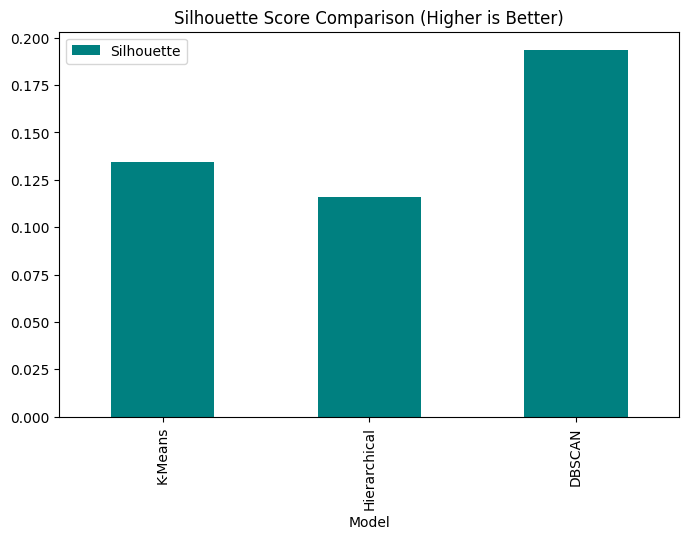

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# 1. Load and Preprocess Data
df = pd.read_csv('data/train.csv')
df_model = df.drop(columns=['Employee_Id'])

le = LabelEncoder()
df_model['Work_Life_Balance'] = le.fit_transform(df_model['Work_Life_Balance'])
df_model['Lives_With_Family'] = le.fit_transform(df_model['Lives_With_Family'])
df_model = pd.get_dummies(df_model, columns=['Work_From', 'Working_State'])

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model.drop(columns=['Stress_Level']))

# 2. Define and Fit Models
results = []

# --- K-Means (k=3) ---
km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_labels = km.fit_predict(X_scaled)
results.append({
    'Model': 'K-Means',
    'Silhouette': silhouette_score(X_scaled, km_labels),
    'Davies-Bouldin': davies_bouldin_score(X_scaled, km_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_scaled, km_labels)
})

# --- Hierarchical (k=3) ---
hier = AgglomerativeClustering(n_clusters=3)
h_labels = hier.fit_predict(X_scaled)
results.append({
    'Model': 'Hierarchical',
    'Silhouette': silhouette_score(X_scaled, h_labels),
    'Davies-Bouldin': davies_bouldin_score(X_scaled, h_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_scaled, h_labels)
})

# --- DBSCAN ---
db = DBSCAN(eps=3.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)
mask = db_labels != -1 # Exclude noise for metrics
results.append({
    'Model': 'DBSCAN',
    'Silhouette': silhouette_score(X_scaled[mask], db_labels[mask]),
    'Davies-Bouldin': davies_bouldin_score(X_scaled[mask], db_labels[mask]),
    'Calinski-Harabasz': calinski_harabasz_score(X_scaled[mask], db_labels[mask])
})

# 3. Create Comparison Table
comparison_df = pd.DataFrame(results)
print("\n--- Final Model Comparison ---")
print(comparison_df)

# 4. Final Visualization: Best Model Selection
comparison_df.set_index('Model')[['Silhouette']].plot(kind='bar', color='teal', figsize=(8,5))
plt.title('Silhouette Score Comparison (Higher is Better)')
plt.show()